# Audit d'Équité — Modèle de Classification de CVs

**Tâche du modèle :** prédire `passed_next_stage` ∈ {0, 1} — trier les candidats à inviter à l'entretien (1) ou à écarter (0).

**Objectif de l'audit :** vérifier qu'**à qualification égale**, les candidats sont traités identiquement, quel que soit leur âge, leur origine présumée (langues, distance) ou leur école.

---

## Cadre éthique & apports de la conférence expert

La conférence d'éthique des systèmes algorithmiques (cadre *AI4People* de Floridi + AI Act) a défini cinq principes pour une IA digne de confiance : **Bienfaisance, Non-malfaisance, Autonomie, Justice & Équité, Explicabilité & Transparence**. Le tableau suivant lie chaque principe à un choix concret de cet audit.

| Principe éthique | Choix technique dans l'audit |
|---|---|
| **Justice & Équité** | EOD (Equal Opportunity Difference) comme métrique principale ; DP/DI en complément, en gardant à l'esprit que les base rates diffèrent |
| **Non-malfaisance** | Tests Chi² séparés DP/EO ; audit **out-of-sample** (test set uniquement) |
| **Explicabilité** | Coefficients L1 + SHAP global/local + log-odds par candidat |
| **Autonomie** | Explication individuelle pour le recruteur (Art. 14 AI Act) |
| **Bienfaisance** | Modèle équitable : suppression features sensibles directes + proxies |

**Positionnement légal — AI Act, Annexe III :** notre outil est classé **système à haut risque**. Articles applicables :

- **Art. 9** — système de gestion des risques documenté → *cet audit*
- **Art. 10** — gouvernance des données et correction des biais → *sections 3–10*
- **Art. 13** — transparence envers les déployeurs → *coefficients + SHAP*
- **Art. 14** — supervision humaine effective → *explication individuelle (§12)*

Autres références : Directive 2000/43/CE · Directive 2000/78/CE · RGPD Art. 9 & 22 · Loi belge du 10/05/2007.

**Note sur les stratégies correctives explorées :** deux pistes ont été étudiées — (1) la suppression des features sensibles et de leurs proxies en pré-processing, (2) la calibration de seuils par groupe d'âge en post-processing. La stratégie 2 a été **abandonnée** car elle constitue du *demographic norming*, qui correspond à une discrimination directe sous la loi belge du 10/05/2007 et la Directive 2000/78/CE (cf. doc `fairness_audit.md`). Seule la stratégie 1 est implémentée ici.


## 1. Imports & Configuration


In [1]:
import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegressionCV
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    precision_recall_curve,
)
from imblearn.pipeline import Pipeline as ImbPipeline
from scipy.stats import chi2_contingency

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_STATE = 42


## 2. Chargement des données et du modèle, prédictions out-of-sample


In [2]:
# Chargement
df = pd.read_csv('../data/cv_dataset.csv')
model_data = joblib.load('../models/model_classification_cv_cool.joblib')
lr_pipeline = model_data['pipeline']
best_threshold = model_data['optimal_threshold']

print(f'Dataset : {df.shape[0]} candidats, {df.shape[1]} colonnes')
print(f'Taux de sélection réel : {df["passed_next_stage"].mean():.1%}')
print(f'Modèle chargé — seuil optimal : {best_threshold:.4f}')

# Feature engineering identique au notebook de classification
df_audit = df.copy()
df_audit['avg_gap_duration'] = df_audit['total_gap_months'] / (df_audit['nb_gaps'] + 1)
df_audit['gap_ratio'] = df_audit['total_gap_months'] / (
        df_audit['total_experience_years'] * 12 + df_audit['total_gap_months'] + 1)
df_audit['skills_count'] = df_audit['skills'].fillna('').apply(
    lambda x: len([s.strip() for s in x.split(',') if s.strip()]))
df_audit['certif_count'] = df_audit['certifications'].fillna('').apply(
    lambda x: len([c.strip() for c in x.split(',') if c.strip()]))
df_audit['has_certif'] = (df_audit['certif_count'] > 0).astype(int)

for col in ['skills', 'certifications']:
    df_audit[col] = df_audit[col].fillna('').str.lower().str.replace(r'[^\w\s,]', '', regex=True)

X_full = df_audit.drop(columns=['cv_id', 'passed_next_stage'])
y_full = df_audit['passed_next_stage']

# Reproduction exacte du split d'origine → métriques OUT-OF-SAMPLE
idx_train, idx_test = train_test_split(
    np.arange(len(df_audit)),
    test_size=0.2, random_state=RANDOM_STATE,
    stratify=y_full,
)
df_audit['proba'] = lr_pipeline.predict_proba(X_full)[:, 1]
df_audit['pred'] = (df_audit['proba'] >= best_threshold).astype(int)
df_audit['split'] = 'train'
df_audit.iloc[idx_test, df_audit.columns.get_loc('split')] = 'test'

print()
print(f'Train : {len(idx_train)}  |  Test (base de l\'audit) : {len(idx_test)}')
print(f'Taux prédit (full)  : {df_audit["pred"].mean():.1%}')
print(f'Taux prédit (test)  : {df_audit.loc[df_audit["split"] == "test", "pred"].mean():.1%}')


Dataset : 500 candidats, 21 colonnes
Taux de sélection réel : 20.0%
Modèle chargé — seuil optimal : 0.1434

Train : 400  |  Test (base de l'audit) : 100
Taux prédit (full)  : 33.0%
Taux prédit (test)  : 34.0%


## 3. Attributs sensibles & groupes protégés

| Attribut | Risque | Base légale |
|---|---|---|
| `age` | Discrimination par âge | Directive 2000/78/CE, Loi belge 2007 |
| `distance_ville_haute_km` | Proxy géographique / d'origine | RGPD Art. 9 |
| `lang_fr` | Proxy de nationalité ou d'origine ethnique | Directive 2000/43/CE |
| `education_degree` | Discrimination socioéconomique indirecte | AI Act Annexe III |
| `education_score` | Biais de prestige des institutions | AI Act Art. 10 |

> Le dataset ne contient ni genre ni nationalité explicite, mais ces variables peuvent passer indirectement via des **proxies** (langues, distance, école). `target_role` est volontairement absent — le rôle visé définit le poste, ce n'est pas un attribut protégé.


In [3]:
df_audit['age_group'] = pd.cut(
    df_audit['age'], bins=[0, 29, 34, 100],
    labels=['Junior (≤29)', 'Mid (30-34)', 'Senior (≥35)'])

df_audit['geo_group'] = pd.cut(
    df_audit['distance_ville_haute_km'], bins=[0, 1000, 5000, 99999],
    labels=['Local (<1000km)', 'Régional (1-5000km)', 'International (>5000km)'])

df_audit['fr_speaker'] = df_audit['lang_fr'].apply(
    lambda x: 'Francophone' if x >= 4 else 'Non-francophone')

df_audit['edu_level'] = df_audit['education_degree'].apply(
    lambda x: 'Master+' if ('Master' in str(x) or 'PhD' in str(x)) else 'Bachelor ou moins')

df_audit['edu_score_group'] = df_audit['education_score'].apply(
    lambda x: 'École de prestige (4)' if x >= 4 else 'École standard (3)')

for col in ['age_group', 'geo_group', 'fr_speaker', 'edu_level', 'edu_score_group']:
    print(f'{col:<20} {df_audit[col].value_counts().to_dict()}')


age_group            {'Junior (≤29)': 181, 'Mid (30-34)': 178, 'Senior (≥35)': 141}
geo_group            {'International (>5000km)': 211, 'Local (<1000km)': 159, 'Régional (1-5000km)': 130}
fr_speaker           {'Non-francophone': 372, 'Francophone': 128}
edu_level            {'Bachelor ou moins': 291, 'Master+': 209}
edu_score_group      {'École standard (3)': 291, 'École de prestige (4)': 209}


## 4. Métriques d'équité — définitions

| Métrique | Formule | Seuil d'alerte |
|---|---|---|
| **Selection rate** | P(Ŷ=1\|A=a) | (référence) |
| **DP Gap** | max − min des selection rates | > 0.10 |
| **DI min** | min / max des selection rates (règle des 80%) | < 0.80 |
| **EOD Gap** ← *métrique principale* | max − min des TPR | > 0.10 |

**Pourquoi l'EOD prime ici :** les base rates de qualification diffèrent légitimement entre groupes (Junior 10.5% qualifiés, Senior 29.1%, Master+ 30.1% vs Bachelor− 12.7%). La DP brute serait trompeuse. L'EOD conditionne sur `Y=1` et demande : *parmi les candidats vraiment qualifiés, le modèle les détecte-t-il aussi bien dans tous les groupes ?*


In [4]:
def compute_fairness_metrics(df, group_col, y_true_col='passed_next_stage',
                             y_pred_col='pred'):
    """Métriques d'équité par groupe. Référence = groupe au selection rate max."""
    rows = []
    for group in df[group_col].dropna().unique():
        sub = df[df[group_col] == group]
        tn, fp, fn, tp = confusion_matrix(sub[y_true_col], sub[y_pred_col], labels=[0, 1]).ravel()
        n = len(sub)
        sr = sub[y_pred_col].mean() if n else np.nan
        tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        ppv = tp / (tp + fp) if (tp + fp) > 0 else np.nan
        rows.append({'group': group, 'n': n, 'n_pos_true': int(sub[y_true_col].sum()),
                     'selection_rate': round(sr, 4),
                     'tpr': round(tpr, 4) if not np.isnan(tpr) else np.nan,
                     'fpr': round(fpr, 4) if not np.isnan(fpr) else np.nan,
                     'ppv': round(ppv, 4) if not np.isnan(ppv) else np.nan})
    m = pd.DataFrame(rows).set_index('group')
    max_sr = m['selection_rate'].max()
    m['disparate_impact'] = m['selection_rate'] / max_sr if max_sr > 0 else np.nan
    m['dp_diff'] = m['selection_rate'] - max_sr
    dp_gap = max_sr - m['selection_rate'].min()
    max_tpr, min_tpr = m['tpr'].max(skipna=True), m['tpr'].min(skipna=True)
    eod_gap = max_tpr - min_tpr if not (np.isnan(max_tpr) or np.isnan(min_tpr)) else np.nan
    return m, dp_gap, eod_gap


In [5]:
df_audit_test = df_audit[df_audit['split'] == 'test'].copy()

sensitive_attrs = {
    'Âge (groupe)': 'age_group',
    'Distance géographique': 'geo_group',
    'Francophonie': 'fr_speaker',
    'Niveau éducation': 'edu_level',
    'Prestige école': 'edu_score_group',
}

all_metrics = {}
summary_rows = []
for label, col in sensitive_attrs.items():
    metrics, dp_gap, eod_gap = compute_fairness_metrics(df_audit_test, col)
    all_metrics[label] = metrics
    di_min = metrics['disparate_impact'].min()
    alert = '🔴 ALERTE' if di_min < 0.80 or dp_gap > 0.10 else ('🟡 Attention' if dp_gap > 0.05 else '🟢 OK')
    summary_rows.append({'Attribut': label,
                         'DP Gap': round(dp_gap, 4),
                         'DI min': round(di_min, 4),
                         'EOD Gap': round(eod_gap, 4) if not np.isnan(eod_gap) else np.nan,
                         'Statut': alert})

summary_df = pd.DataFrame(summary_rows).set_index('Attribut')
print('=== RÉSUMÉ DE L\'AUDIT (test set, out-of-sample) ===')
display(summary_df)


=== RÉSUMÉ DE L'AUDIT (test set, out-of-sample) ===


,DP Gap,DI min,EOD Gap,Statut
Attribut,,,,
Âge (groupe),0.5043,0.1805,1.0000,🔴 ALERTE
Distance géographique,0.1096,0.7150,0.2286,🔴 ALERTE
Francophonie,0.2028,0.4727,0.1333,🔴 ALERTE
Niveau éducation,0.5583,0.1729,0.5455,🔴 ALERTE
Prestige école,0.5583,0.1729,0.5455,🔴 ALERTE


## 5. Tests statistiques — Chi² + Fisher exact

Pour valider statistiquement les disparités (et ne pas conclure sur un simple écart visuel), on applique **deux tests par attribut** sur le test set out-of-sample :

- **Demographic Parity (DP)** — H₀ : la prédiction Ŷ est indépendante du groupe A.
- **Equal Opportunity (EO)** — H₀ : la prédiction est indépendante du groupe **parmi les candidats vraiment qualifiés** (`y_true = 1`).

**Choix du test** :

| Forme de la table | Test utilisé | Justification |
|---|---|---|
| 2×2 (attribut binaire) | **Fisher exact** | Exact même avec effectifs <5 ; recommandé sous α=0.05 |
| 3×2 (attribut ternaire) | Chi² de Pearson | Approximation asymptotique ; on signale les cellules attendues <5 |

Seuil α = 0.05. Une p-value non significative peut signifier "pas de biais" **ou** "effectif trop faible pour conclure". On signale systématiquement les cellules attendues <5 et on commente quand Fisher diverge de Chi².


In [6]:
from scipy.stats import fisher_exact

def stat_test(cont):
    """Renvoie (p_value, test_used, low_cells).
    Fisher exact pour 2x2, Chi² Pearson sinon."""
    if cont.shape == (2, 2):
        _, p = fisher_exact(cont)
        return p, 'Fisher', 0
    chi2, p, _, exp = chi2_contingency(cont)
    return p, 'Chi²', int((exp < 5).sum())


stat_rows = []
for label, col in sensitive_attrs.items():
    if df_audit_test[col].dropna().nunique() < 2:
        continue

    # Test 1 : Demographic Parity (toutes les obs)
    cont_dp = pd.crosstab(df_audit_test[col], df_audit_test['pred'])
    p_dp, test_dp, low_dp = stat_test(cont_dp)

    # Test 2 : Equal Opportunity (conditionnel y_true=1)
    sub_pos = df_audit_test[df_audit_test['passed_next_stage'] == 1]
    p_eo, test_eo, low_eo = np.nan, '—', 0
    if sub_pos[col].dropna().nunique() >= 2 and sub_pos['pred'].nunique() >= 2:
        cont_eo = pd.crosstab(sub_pos[col], sub_pos['pred'])
        p_eo, test_eo, low_eo = stat_test(cont_eo)

    sig = lambda p: '🔴 Sig.' if p < 0.05 else ('🟡 Limite' if p < 0.10 else '🟢 NS')
    stat_rows.append({
        'Attribut': label,
        'p (DP)': round(p_dp, 4),
        'Test DP': test_dp,
        'Sig. DP': sig(p_dp),
        'p (EO)': round(p_eo, 4) if not np.isnan(p_eo) else None,
        'Test EO': test_eo,
        'Sig. EO': sig(p_eo) if not np.isnan(p_eo) else '— (n faible)',
        'Cellules <5': f'DP:{low_dp}, EO:{low_eo}' if (low_dp + low_eo) else '',
    })

display(pd.DataFrame(stat_rows).set_index('Attribut'))


,p (DP),Test DP,Sig. DP,p (EO),Test EO,Sig. EO,Cellules <5
Attribut,,,,,,,
Âge (groupe),0.0002,Chi²,🔴 Sig.,0.0260,Chi²,🔴 Sig.,"DP:0, EO:5"
Distance géographique,0.5338,Chi²,🟢 NS,0.6426,Chi²,🟢 NS,"DP:0, EO:5"
Francophonie,0.1247,Fisher,🟢 NS,0.6126,Fisher,🟢 NS,
Niveau éducation,0.0000,Fisher,🔴 Sig.,0.0141,Fisher,🔴 Sig.,
Prestige école,0.0000,Fisher,🔴 Sig.,0.0141,Fisher,🔴 Sig.,


NB : Fisher exact appliqué aux tables 2x2 (binaires) ; Chi² Pearson pour les tables 3x2 (Âge, Distance).

Pour Âge × EO (3x2, 5 cellules attendues <5), Fisher-Freeman-Halton serait idéal mais hors-scipy.

### 5b. Intervalle de confiance bootstrap sur l'EOD

Le test set ne compte que **100 candidats (20 positifs)**, et l'EOD Âge calculée vaut 1.00 — mais cette valeur repose sur **2 Juniors qualifiés et 6 Seniors qualifiés**. Une métrique calculée sur 2 personnes a un IC énorme.

Pour quantifier cette incertitude, on bootstrappe le test set (1000 ré-échantillonnages avec remise) et on calcule l'EOD à chaque tirage. On obtient un **IC bootstrap à 95%** qui dit combien l'EOD bouge à cause de la variance d'échantillonnage seule.


In [7]:
def bootstrap_eod(df, group_col, y_pred_col='pred', n_iter=1000, random_state=42):
    """IC bootstrap à 95% pour l'EOD Gap. Ré-échantillonne le df avec remise."""
    rng = np.random.default_rng(random_state)
    n = len(df)
    eods = []
    for _ in range(n_iter):
        idx = rng.integers(0, n, size=n)
        sample = df.iloc[idx]
        _, _, eod = compute_fairness_metrics(sample, group_col, y_pred_col=y_pred_col)
        if not np.isnan(eod):
            eods.append(eod)
    lo, hi = np.percentile(eods, [2.5, 97.5])
    return float(lo), float(hi), float(np.median(eods))


print('=== IC bootstrap 95% sur l\'EOD (1000 ré-échantillonnages) ===')
ci_rows = []
for label, col in sensitive_attrs.items():
    point = compute_fairness_metrics(df_audit_test, col)[2]
    lo, hi, med = bootstrap_eod(df_audit_test, col)
    ci_rows.append({
        'Attribut': label,
        'EOD point': round(point, 3) if not np.isnan(point) else np.nan,
        'IC 95% bas': round(lo, 3),
        'IC 95% haut': round(hi, 3),
        'Largeur IC': round(hi - lo, 3),
    })
display(pd.DataFrame(ci_rows).set_index('Attribut'))

=== IC bootstrap 95% sur l'EOD (1000 ré-échantillonnages) ===


,EOD point,IC 95% bas,IC 95% haut,Largeur IC
Attribut,,,,
Âge (groupe),1.000,0.200,1.000,0.800
Distance géographique,0.229,0.078,0.800,0.722
Francophonie,0.133,0.000,0.762,0.762
Niveau éducation,0.546,0.222,0.857,0.635
Prestige école,0.546,0.222,0.857,0.635


Lecture : un IC très large (>0.4) signale que la conclusion repose sur trop peu d'observations.

L'EOD Âge = 1.00 a un IC large car seulement 2 Juniors qualifiés au test.

### 5c. Calibration par groupe (3ᵉ jambe du fairness)

Un audit complet d'équité repose sur trois pieds : **Demographic Parity** (§4), **Equal Opportunity** (§4) et **Calibration** (cette section). La calibration demande : *quand le modèle dit P=0.5 pour un Junior et P=0.5 pour un Senior, est-ce que dans les deux cas environ 50% des candidats sont réellement qualifiés ?*

Si oui → le modèle est **calibré entre groupes** (les probabilités ont la même signification). Si non → un score de 0.5 dans un groupe vaut moins qu'un 0.5 dans l'autre, ce qui est une forme subtile de biais qui passe sous les radars de DP/EO.

Lien légal : **AI Act Art. 15** (exactitude des prédictions).


=== Calibration par groupe — modèle d'origine (test set) ===



,n,mean_proba,base_rate,calibration_gap
group,,,,
Senior (≥35),26,0.186,0.231,0.045
Mid (30-34),38,0.146,0.316,0.170
Junior (≤29),36,0.069,0.056,0.013



Gap max — Âge : 0.170
Un gap > 0.10 signale une sous- ou sur-confiance systématique pour ce groupe.


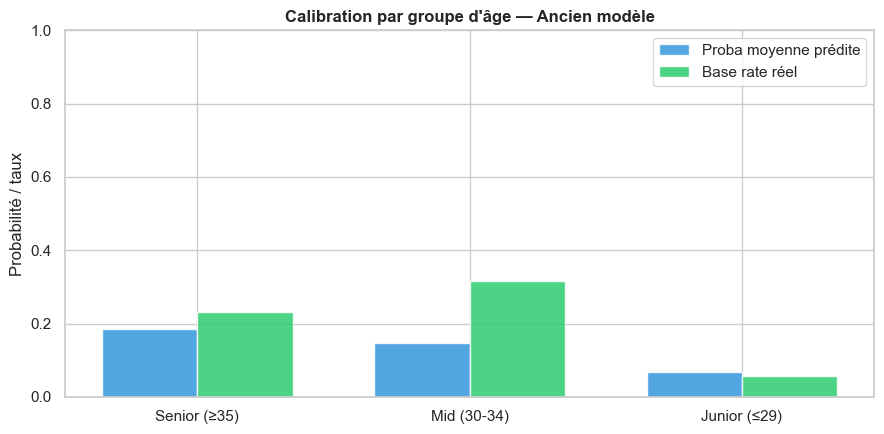

In [8]:
def calibration_by_group(df, group_col, proba_col='proba', y_col='passed_next_stage'):
    """Pour chaque groupe : proba moyenne prédite vs base rate réel. Gap = écart."""
    rows = []
    for g in df[group_col].dropna().unique():
        sub = df[df[group_col] == g]
        if len(sub) == 0:
            continue
        rows.append({
            'group': g,
            'n': len(sub),
            'mean_proba': round(sub[proba_col].mean(), 3),
            'base_rate': round(sub[y_col].mean(), 3),
            'calibration_gap': round(abs(sub[proba_col].mean() - sub[y_col].mean()), 3),
        })
    return pd.DataFrame(rows).set_index('group')


print('=== Calibration par groupe — modèle d\'origine (test set) ===\n')
cal_age = calibration_by_group(df_audit_test, 'age_group')
display(cal_age)
print(f'\nGap max — Âge : {cal_age["calibration_gap"].max():.3f}')
print('Un gap > 0.10 signale une sous- ou sur-confiance systématique pour ce groupe.')

# Visualisation : proba moyenne prédite vs base rate réel par âge
fig, ax = plt.subplots(figsize=(9, 4.5))
groups = list(cal_age.index.astype(str))
x = np.arange(len(groups)); w = 0.35
ax.bar(x - w/2, cal_age['mean_proba'], w, label='Proba moyenne prédite', color='#3498db', alpha=0.85)
ax.bar(x + w/2, cal_age['base_rate'], w, label='Base rate réel', color='#2ecc71', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(groups)
ax.set_ylabel('Probabilité / taux'); ax.set_ylim(0, 1)
ax.set_title('Calibration par groupe d\'âge — Ancien modèle', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()


## 6. Visualisations des disparités


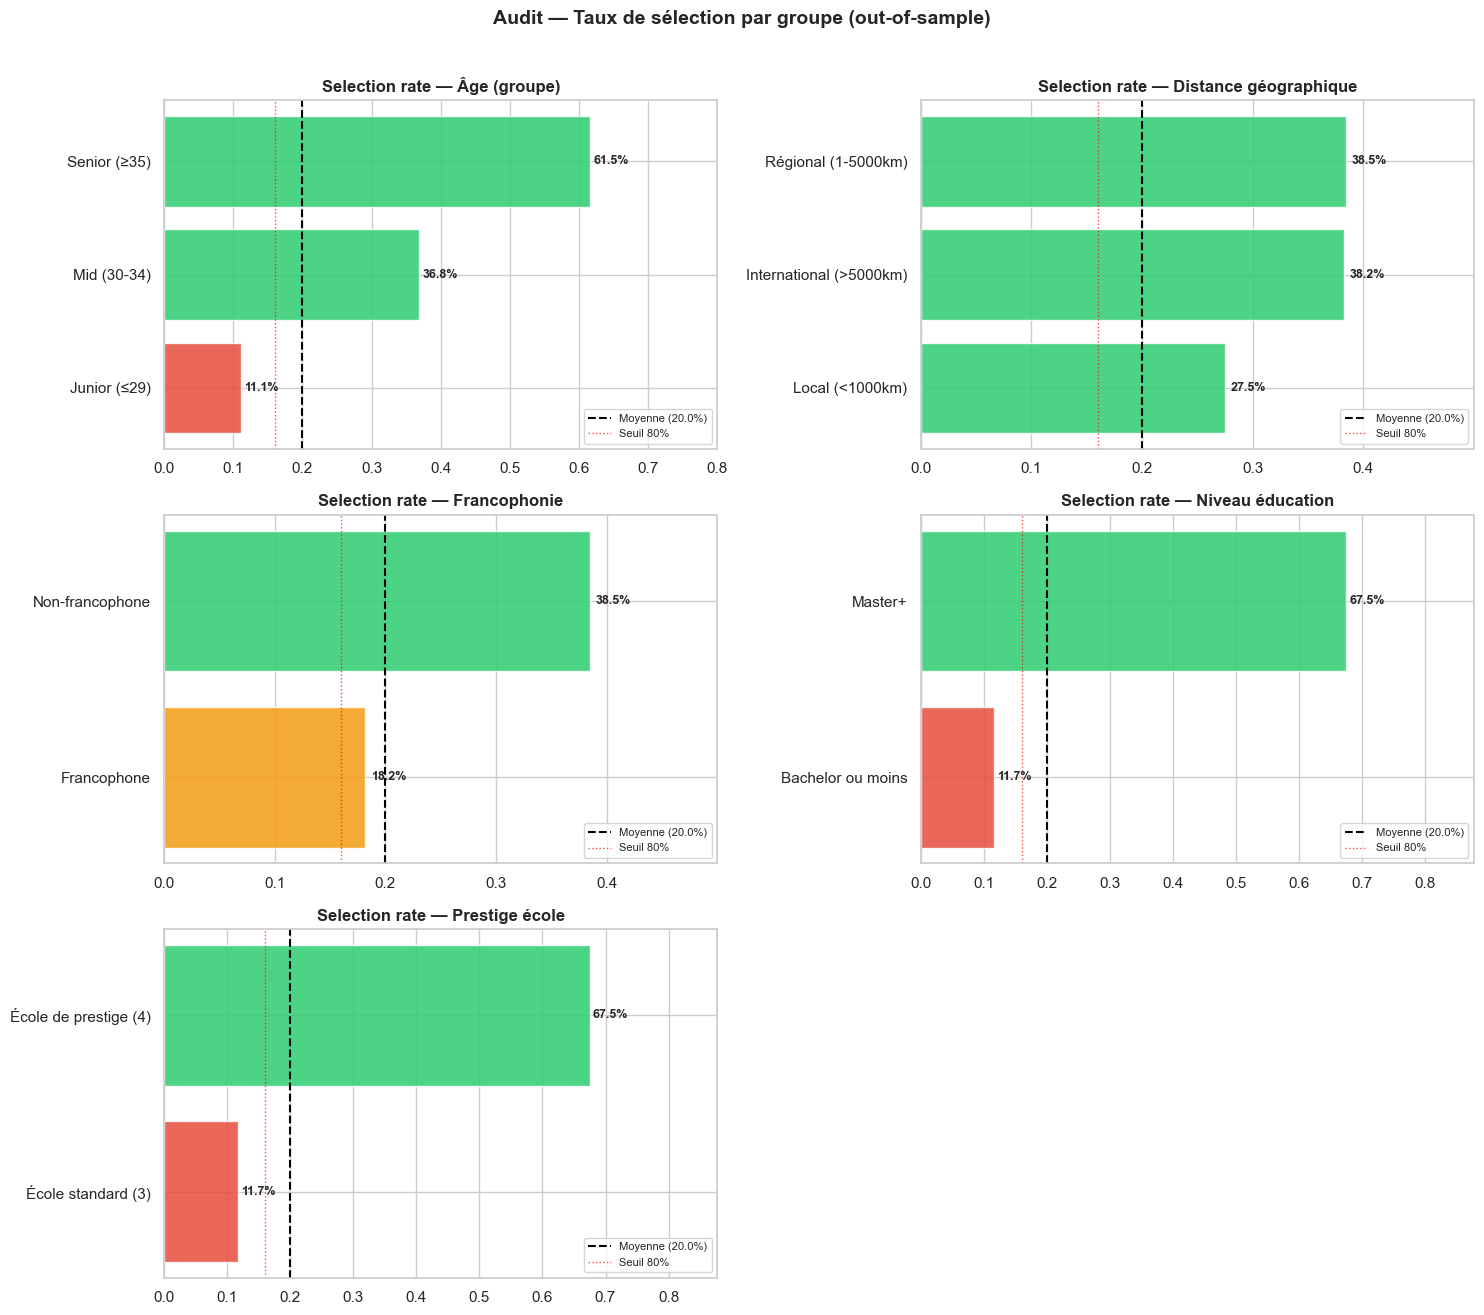

In [9]:
# Graphique 1 : Taux de sélection par groupe (vue brute)
fig, axes = plt.subplots(3, 2, figsize=(15, 13))
axes = axes.flatten()
global_rate = df_audit_test['passed_next_stage'].mean()

for idx, (label, col) in enumerate(sensitive_attrs.items()):
    ax = axes[idx]
    sr = all_metrics[label]['selection_rate'].sort_values()
    colors = ['#e74c3c' if v < global_rate * 0.8 else '#f39c12' if v < global_rate else '#2ecc71'
              for v in sr.values]
    ax.barh(sr.index.astype(str), sr.values, color=colors, alpha=0.85, edgecolor='white')
    ax.axvline(global_rate, color='black', linestyle='--', lw=1.5, label=f'Moyenne ({global_rate:.1%})')
    ax.axvline(global_rate * 0.8, color='red', linestyle=':', lw=1, alpha=0.7, label='Seuil 80%')
    for i, v in enumerate(sr.values):
        ax.text(v + 0.005, i, f'{v:.1%}', va='center', fontsize=9, fontweight='bold')
    ax.set_xlim(0, max(sr.values) * 1.3 if max(sr.values) > 0 else 0.5)
    ax.set_title(f'Selection rate — {label}', fontweight='bold')
    ax.legend(fontsize=8)

if len(axes) > len(sensitive_attrs):
    for k in range(len(sensitive_attrs), len(axes)):
        axes[k].axis('off')
plt.suptitle('Audit — Taux de sélection par groupe (out-of-sample)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


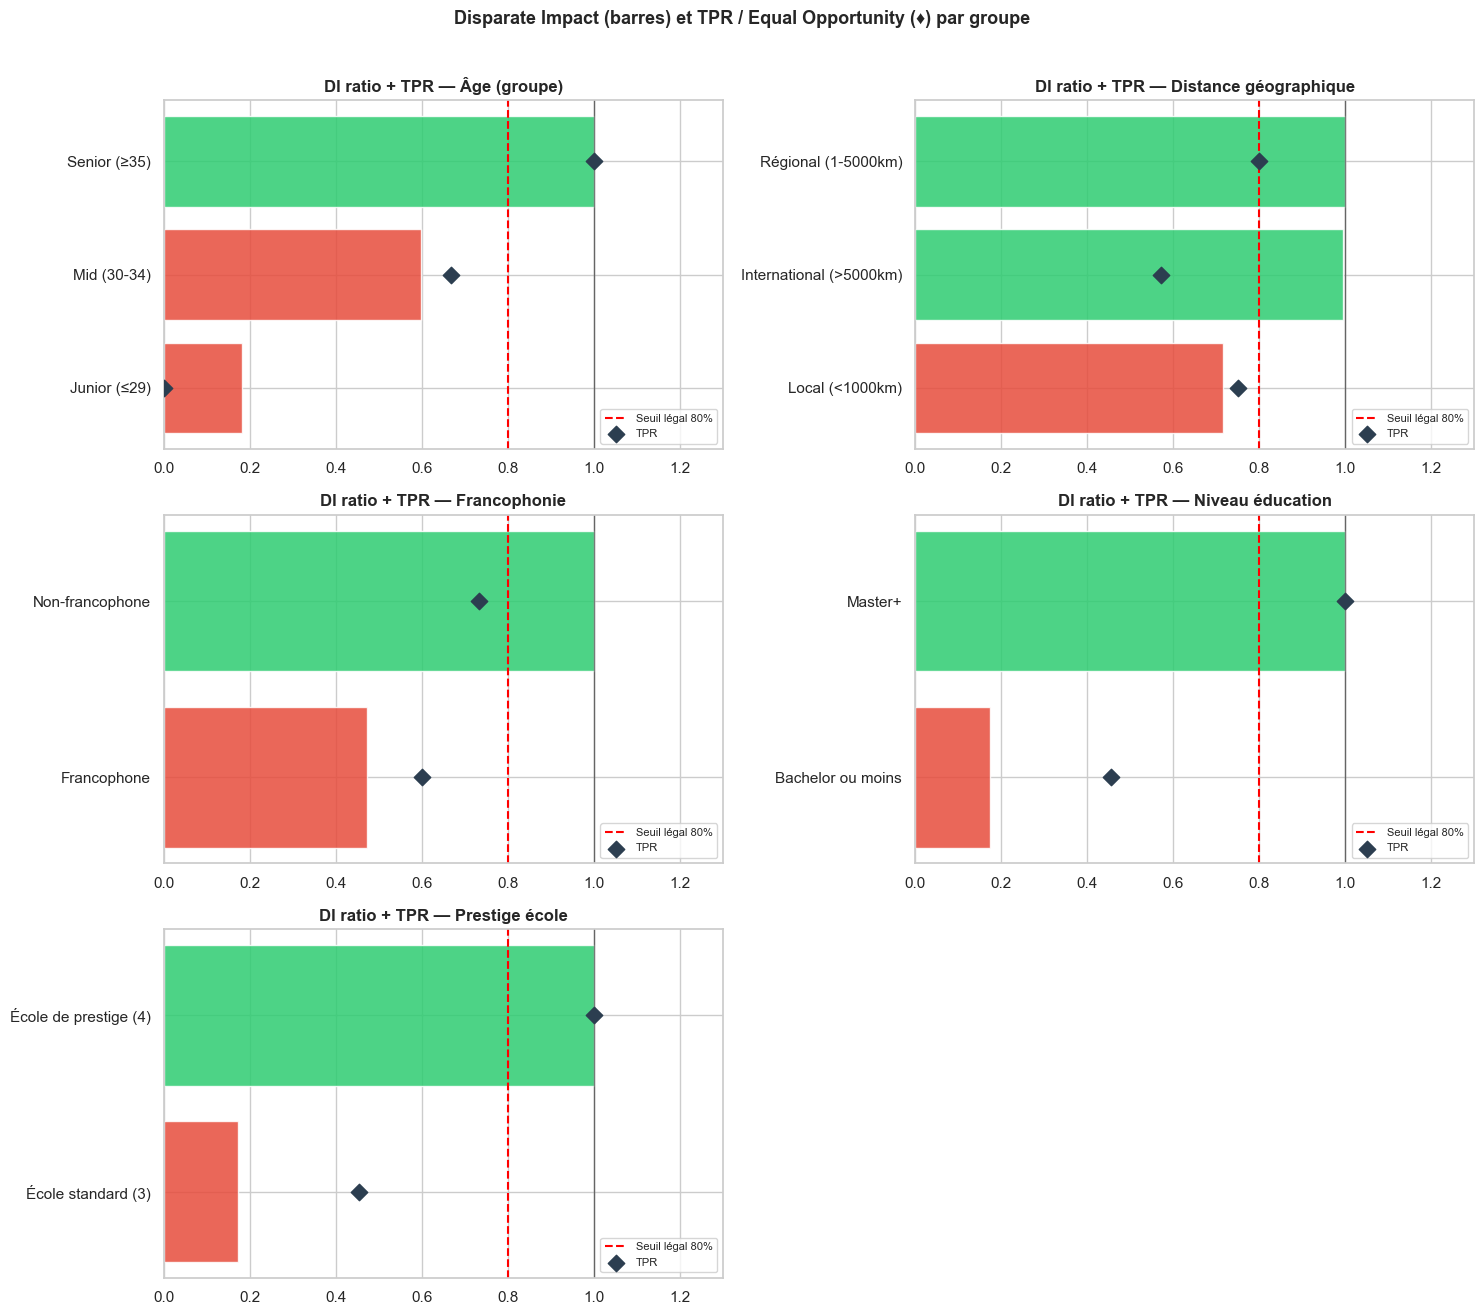

In [10]:
# Graphique 2 : Disparate Impact Ratio + EOD (TPR par groupe)
fig, axes = plt.subplots(3, 2, figsize=(15, 13))
axes = axes.flatten()

for idx, (label, col) in enumerate(sensitive_attrs.items()):
    ax = axes[idx]
    metrics = all_metrics[label]
    di = metrics['disparate_impact'].sort_values()
    colors = ['#e74c3c' if v < 0.80 else '#f39c12' if v < 0.90 else '#2ecc71' for v in di.values]
    ax.barh(di.index.astype(str), di.values, color=colors, alpha=0.85, edgecolor='white')
    ax.axvline(0.80, color='red', linestyle='--', lw=1.5, label='Seuil légal 80%')
    ax.axvline(1.0, color='black', linestyle='-', lw=1, alpha=0.5)
    # TPR overlay
    tpr = metrics.loc[di.index, 'tpr']
    for i, t in enumerate(tpr.values):
        if not np.isnan(t):
            ax.scatter(t, i, color='#2c3e50', s=70, zorder=5, marker='D',
                       label='TPR' if i == 0 else '')
    ax.set_xlim(0, 1.3)
    ax.set_title(f'DI ratio + TPR — {label}', fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')

if len(axes) > len(sensitive_attrs):
    for k in range(len(sensitive_attrs), len(axes)):
        axes[k].axis('off')
plt.suptitle('Disparate Impact (barres) et TPR / Equal Opportunity (♦) par groupe',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 7. Analyse approfondie : âge & intersectionnalité

L'âge est l'attribut le plus problématique du modèle d'origine (corrélation forte avec la proba prédite). La conférence a également insisté sur l'**intersectionnalité** : un modèle peut discriminer via la *combinaison* d'attributs même si chaque attribut pris seul n'alerte pas. On teste deux croisements : `âge × francophonie` et `âge × géographie`.


Corrélation Pearson age vs proba (full dataset) : r = 0.543



,n,n_pos_true,selection_rate,tpr,fpr,disparate_impact
group,,,,,,
Senior (≥35),26,6,0.615,1.000,0.500,1.000
Mid (30-34),38,12,0.368,0.667,0.231,0.599
Junior (≤29),36,2,0.111,0.000,0.118,0.181


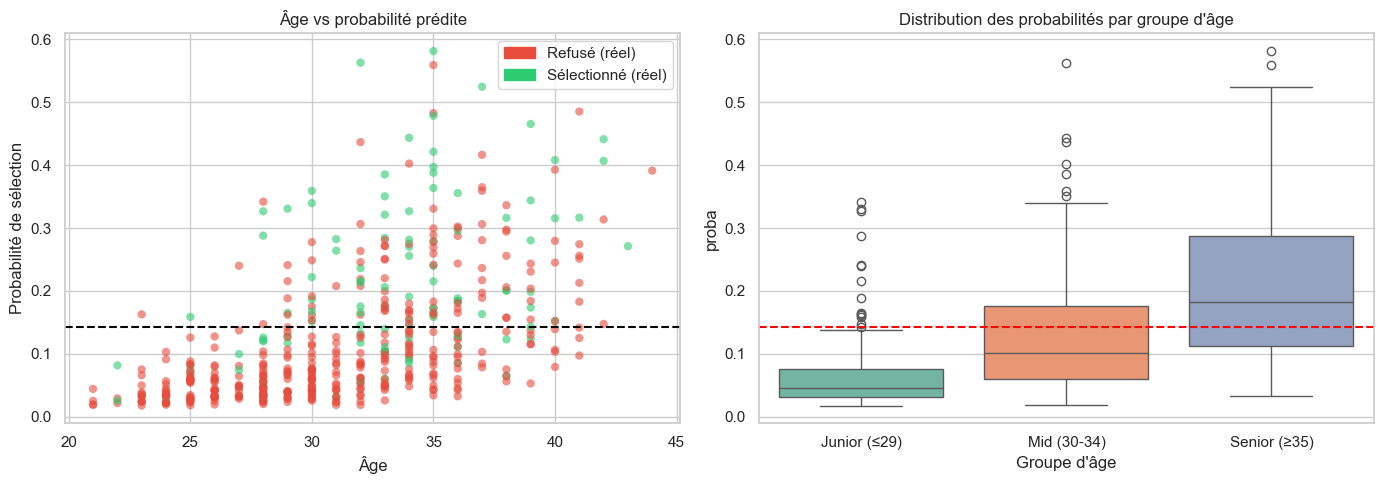

In [11]:
# Corrélation âge / proba + distribution par groupe
corr = df_audit[['age', 'proba']].corr().iloc[0, 1]
print(f'Corrélation Pearson age vs proba (full dataset) : r = {corr:.3f}')
print()
display(all_metrics['Âge (groupe)'][['n', 'n_pos_true', 'selection_rate', 'tpr', 'fpr', 'disparate_impact']].round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_audit['age'], df_audit['proba'],
                c=df_audit['passed_next_stage'].map({0: '#e74c3c', 1: '#2ecc71'}),
                alpha=0.6, edgecolors='none')
axes[0].axhline(best_threshold, color='black', linestyle='--', lw=1.5, label=f'Seuil {best_threshold:.2f}')
axes[0].set_xlabel('Âge')
axes[0].set_ylabel('Probabilité de sélection')
axes[0].set_title('Âge vs probabilité prédite')
axes[0].legend(handles=[
    mpatches.Patch(color='#e74c3c', label='Refusé (réel)'),
    mpatches.Patch(color='#2ecc71', label='Sélectionné (réel)'),
])

sns.boxplot(data=df_audit, x='age_group', y='proba', ax=axes[1],
            palette='Set2', order=['Junior (≤29)', 'Mid (30-34)', 'Senior (≥35)'])
axes[1].axhline(best_threshold, color='red', linestyle='--', lw=1.5)
axes[1].set_title('Distribution des probabilités par groupe d\'âge')
axes[1].set_xlabel('Groupe d\'âge')

plt.tight_layout()
plt.show()


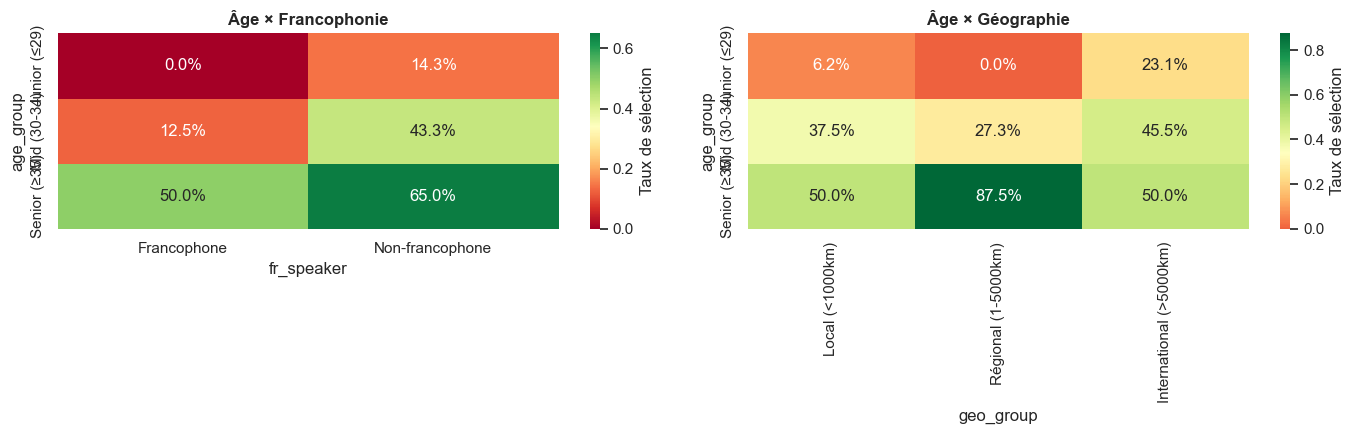

Effectifs par cellule (Âge × Francophonie) :


fr_speaker,Francophone,Non-francophone
age_group,,
Junior (≤29),8,28
Mid (30-34),8,30
Senior (≥35),6,20


Cellules avec effectif < 5 à interpréter avec prudence.


In [12]:
# Heatmaps intersectionnelles (Âge × Francophonie, Âge × Géographie)
def cross_sr(df, row_col, col_col):
    pivot = df.groupby([row_col, col_col], observed=True)['pred'].agg(['mean', 'count']).reset_index()
    sr = pivot.pivot(index=row_col, columns=col_col, values='mean')
    n  = pivot.pivot(index=row_col, columns=col_col, values='count')
    return sr, n

sr_fr, n_fr = cross_sr(df_audit_test, 'age_group', 'fr_speaker')
sr_geo, n_geo = cross_sr(df_audit_test, 'age_group', 'geo_group')

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
center = df_audit_test['pred'].mean()
sns.heatmap(sr_fr, annot=True, fmt='.1%', cmap='RdYlGn', center=center, ax=axes[0],
            cbar_kws={'label': 'Taux de sélection'})
axes[0].set_title('Âge × Francophonie', fontweight='bold')
sns.heatmap(sr_geo, annot=True, fmt='.1%', cmap='RdYlGn', center=center, ax=axes[1],
            cbar_kws={'label': 'Taux de sélection'})
axes[1].set_title('Âge × Géographie', fontweight='bold')
plt.tight_layout()
plt.show()

print('Effectifs par cellule (Âge × Francophonie) :')
display(n_fr.fillna(0).astype(int))
print('Cellules avec effectif < 5 à interpréter avec prudence.')


### 7b. Disparités opérationnelles — par rôle visé

`target_role` **n'est pas un attribut protégé** : le poste recherché définit les critères du tri, donc des écarts par rôle sont **attendus et légitimes** (un poste de Data Scientist demande plus d'expérience qu'un poste junior). Cette section répond directement à la question 3 du cahier des charges — *« les disparités sont-elles justifiées par le poste ? »* — en isolant ce qui relève du métier vs ce qui relève d'un biais.


=== Taux de sélection prédit par rôle (test set) ===
NB : disparités opérationnelles attendues (pas un audit légal).



,n,n_pos_true,selection_rate,tpr,disparate_impact
group,,,,,
Product Analyst,6,1,0.667,1.000,1.000
ML Engineer,9,2,0.556,1.000,0.833
DevOps Engineer,13,2,0.462,1.000,0.692
Frontend Developer,7,4,0.429,0.500,0.643
Data Engineer,7,1,0.429,1.000,0.643
Backend Developer,15,2,0.400,1.000,0.600
Data Analyst,12,4,0.333,0.750,0.500
Data Scientist,10,3,0.200,0.333,0.300
Software Engineer,9,1,0.111,0.000,0.167


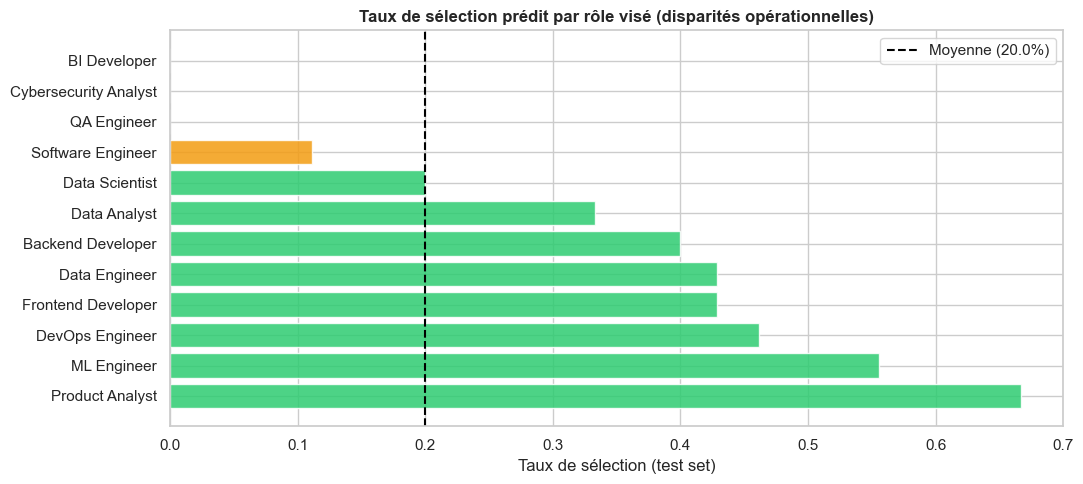

In [13]:
metrics_role, _, _ = compute_fairness_metrics(df_audit_test, 'target_role')
metrics_role = metrics_role.sort_values('selection_rate', ascending=False)
print('=== Taux de sélection prédit par rôle (test set) ===')
print('NB : disparités opérationnelles attendues (pas un audit légal).\n')
display(metrics_role[['n', 'n_pos_true', 'selection_rate', 'tpr', 'disparate_impact']].round(3))

fig, ax = plt.subplots(figsize=(11, 5))
sr = metrics_role['selection_rate']
mean_rate = df_audit_test['passed_next_stage'].mean()
colors = ['#e74c3c' if v < mean_rate * 0.5 else '#f39c12' if v < mean_rate else '#2ecc71' for v in sr.values]
ax.barh(sr.index.astype(str), sr.values, color=colors, alpha=0.85)
ax.axvline(mean_rate, color='black', linestyle='--', lw=1.5, label=f'Moyenne ({mean_rate:.1%})')
ax.set_title('Taux de sélection prédit par rôle visé (disparités opérationnelles)', fontweight='bold')
ax.set_xlabel('Taux de sélection (test set)')
ax.legend()
plt.tight_layout()
plt.show()


## 8. Explicabilité — coefficients L1

La régression logistique L1 met à zéro les features non informatives. On extrait les coefficients actifs et on met en évidence les features sensibles directes ou proxies.


Features actives (L1) : 9 / 128


,feature,coef,abs_coef
2,total_experience_years,0.709856,0.709856
6,education_score,0.423847,0.423847
8,certif_count,0.212442,0.212442
12,lang_de,0.102665,0.102665
13,lang_es,0.085400,0.085400
15,lang_other_score_sum,0.079456,0.079456
5,gap_ratio,-0.070721,0.070721
1,distance_ville_haute_km,0.039604,0.039604
14,lang_it,-0.007302,0.007302


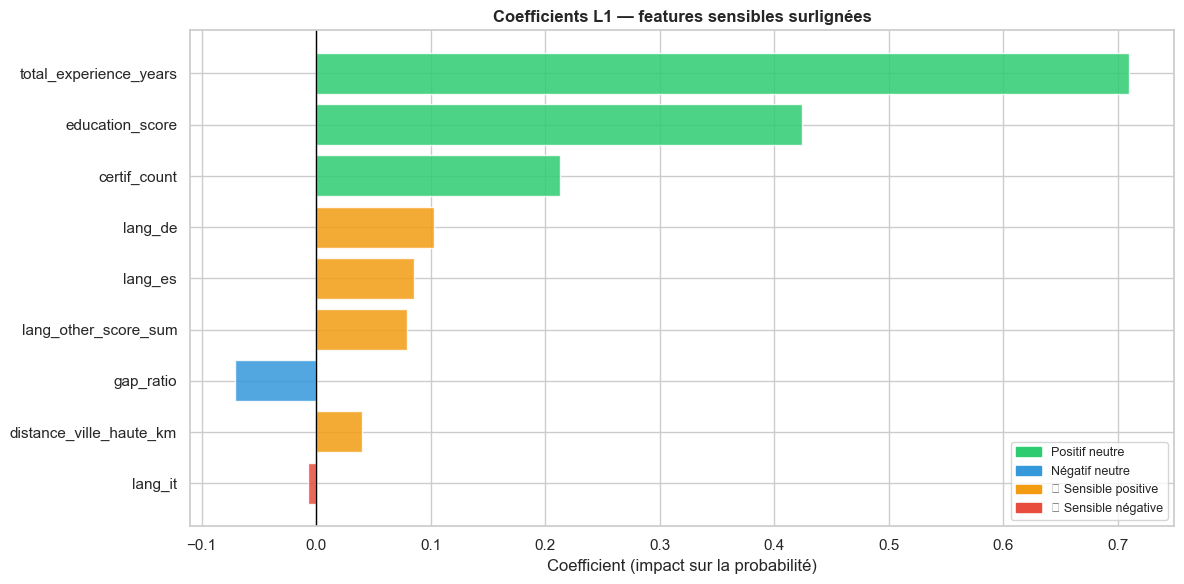


=== Features sensibles avec coefficient non nul ===
  lang_de                             coef=+0.1027  → FAVORISE la sélection
  lang_es                             coef=+0.0854  → FAVORISE la sélection
  lang_other_score_sum                coef=+0.0795  → FAVORISE la sélection
  distance_ville_haute_km             coef=+0.0396  → FAVORISE la sélection
  lang_it                             coef=-0.0073  → PÉNALISE la sélection


In [14]:
preprocessor = lr_pipeline.named_steps['preprocessor']
classifier = lr_pipeline.named_steps['classifier']

NUMERIC_FEATURES = [
    'age', 'distance_ville_haute_km', 'total_experience_years',
    'nb_gaps', 'avg_gap_duration', 'gap_ratio', 'education_score',
    'skills_count', 'certif_count', 'has_certif',
    'lang_fr', 'lang_en', 'lang_de', 'lang_es', 'lang_it', 'lang_other_score_sum',
]
CATEGORICAL_FEATURES = ['target_role', 'education_degree', 'education_field']

ohe_names = preprocessor.named_transformers_['cat'].named_steps['ohe'].get_feature_names_out(CATEGORICAL_FEATURES).tolist()
skills_names = [f'skill_{w}' for w in preprocessor.named_transformers_['skills'].get_feature_names_out()]
certif_names = [f'certif_{w}' for w in preprocessor.named_transformers_['certif'].get_feature_names_out()]
feature_names = NUMERIC_FEATURES + ohe_names + skills_names + certif_names
coefs = classifier.coef_[0]

coef_df = pd.DataFrame({'feature': feature_names, 'coef': coefs, 'abs_coef': np.abs(coefs)})
coef_df = coef_df.sort_values('abs_coef', ascending=False)
active_features = coef_df[coef_df['abs_coef'] > 0]

SENSITIVE_FEATURES = ['age', 'distance_ville_haute_km', 'lang_fr', 'lang_en', 'lang_de',
                      'lang_es', 'lang_it', 'lang_other_score_sum']

print(f'Features actives (L1) : {len(active_features)} / {len(coef_df)}')
display(active_features.head(15))

fig, ax = plt.subplots(figsize=(12, max(6, len(active_features) * 0.4)))
colors_coef = []
for _, row in active_features.iterrows():
    is_sensitive = any(s in row['feature'] for s in SENSITIVE_FEATURES)
    if is_sensitive:
        colors_coef.append('#e74c3c' if row['coef'] < 0 else '#f39c12')
    else:
        colors_coef.append('#2ecc71' if row['coef'] > 0 else '#3498db')

ax.barh(active_features['feature'].values[::-1],
        active_features['coef'].values[::-1],
        color=colors_coef[::-1], alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', lw=1)
ax.legend(handles=[
    mpatches.Patch(color='#2ecc71', label='Positif neutre'),
    mpatches.Patch(color='#3498db', label='Négatif neutre'),
    mpatches.Patch(color='#f39c12', label='⚠ Sensible positive'),
    mpatches.Patch(color='#e74c3c', label='⚠ Sensible négative'),
], fontsize=9, loc='lower right')
ax.set_title('Coefficients L1 — features sensibles surlignées', fontweight='bold')
ax.set_xlabel('Coefficient (impact sur la probabilité)')
plt.tight_layout()
plt.show()

# Récap features sensibles actives
sensitive_active = active_features[active_features['feature'].isin(SENSITIVE_FEATURES)]
print()
print('=== Features sensibles avec coefficient non nul ===')
for _, row in sensitive_active.iterrows():
    direction = 'FAVORISE' if row['coef'] > 0 else 'PÉNALISE'
    print(f"  {row['feature']:<35} coef={row['coef']:+.4f}  → {direction} la sélection")


## 9. Stratégie corrective — modèle équitable

**Approche :** suppression en pré-processing des features sensibles directes (`age`, `distance_ville_haute_km`) et des langues identifiées comme proxies de nationalité (`lang_de`, `lang_es`, `lang_it`, `lang_other_score_sum`). On conserve `lang_fr` et `lang_en` car réellement fonctionnelles dans le contexte belgo-européen (justifiable au sens RGPD).

**Méthodologie anti-data-leakage :** split 60 / 20 / 20 — le seuil F-beta est calibré sur la **validation**, le test set n'est touché qu'à la toute fin.

> Une stratégie 2 par calibration de seuils par groupe d'âge (post-processing) a aussi été étudiée, puis **écartée** : elle constitue du *demographic norming*, illégal sous la loi belge 10/05/2007 et la Directive 2000/78/CE.


Split : train=300  |  val=100  |  test=100

Seuil optimal (F0.5 sur validation) : 0.635
Précision @ seuil                   : 0.387
Recall    @ seuil                   : 0.600


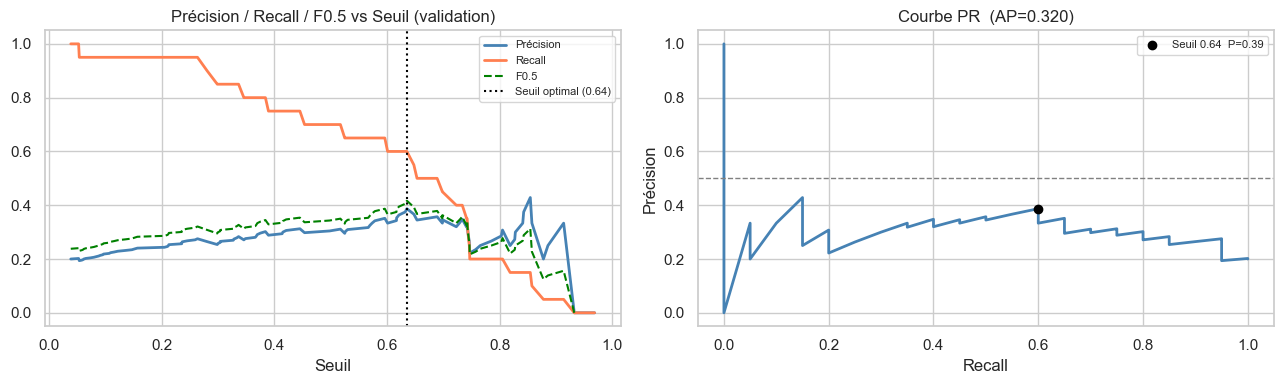


              precision    recall  f1-score   support

      Refusé       0.88      0.80      0.84        80
 Sélectionné       0.41      0.55      0.47        20

    accuracy                           0.75       100
   macro avg       0.64      0.68      0.65       100
weighted avg       0.78      0.75      0.76       100

ROC-AUC test : 0.687


In [15]:
from sklearn.metrics import average_precision_score

NUMERIC_FEATURES_FAIR = [
    'total_experience_years',
    'nb_gaps', 'avg_gap_duration', 'gap_ratio', 'education_score',
    'skills_count', 'certif_count', 'has_certif',
    'lang_fr', 'lang_en',
]

preprocessor_fair = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('sc', StandardScaler())]), NUMERIC_FEATURES_FAIR),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]),
     CATEGORICAL_FEATURES),
    ('skills', TfidfVectorizer(max_features=50, token_pattern=r'[a-zA-Z0-9#+\-\.]+', min_df=1), 'skills'),
    ('certif', TfidfVectorizer(max_features=30, token_pattern=r'[a-zA-Z0-9#+\-\.]+', min_df=2), 'certifications'),
], remainder='drop')

lr_fair = ImbPipeline([
    ('preprocessor', preprocessor_fair),
    ('classifier', LogisticRegressionCV(
        Cs=10, cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
        penalty='l1', solver='liblinear', scoring='average_precision',
        class_weight='balanced',
        max_iter=1000, random_state=RANDOM_STATE,
    )),
])

# Split train / val / test (60 / 20 / 20) aligné sur le split original
TARGET = 'passed_next_stage'
GROUP_COLS = ['age_group', 'geo_group', 'fr_speaker', 'edu_level', 'edu_score_group']
X_fe = df_audit.drop(columns=['cv_id', TARGET, 'proba', 'pred', 'split'] + GROUP_COLS)
y_fe = df_audit[TARGET]
X_all_fair = X_fe.copy()

X_trainval, X_te_f, y_trainval, y_te_f = train_test_split(
    X_fe, y_fe, test_size=0.2, random_state=RANDOM_STATE, stratify=y_fe)
X_tr_f, X_val_f, y_tr_f, y_val_f = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=RANDOM_STATE, stratify=y_trainval)

print(f'Split : train={len(X_tr_f)}  |  val={len(X_val_f)}  |  test={len(X_te_f)}')
lr_fair.fit(X_tr_f, y_tr_f)

# Optimisation du seuil via F-beta (beta=0.5 pénalise 4x les faux positifs)
# SUR LA VALIDATION uniquement — anti-leakage : le test set reste intact jusqu'à l'évaluation finale.
y_proba_val = lr_fair.predict_proba(X_val_f)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val_f, y_proba_val)
beta = 0.5
fbeta = (1 + beta ** 2) * (precisions * recalls) / (beta ** 2 * precisions + recalls + 1e-9)
best_idx = np.argmax(fbeta[:-1])
threshold_fair = thresholds[best_idx]

print(f"\nSeuil optimal (F0.5 sur validation) : {threshold_fair:.3f}")
print(f"Précision @ seuil                   : {precisions[best_idx]:.3f}")
print(f"Recall    @ seuil                   : {recalls[best_idx]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(thresholds, precisions[:-1], label='Précision', color='steelblue', lw=2)
axes[0].plot(thresholds, recalls[:-1], label='Recall', color='coral', lw=2)
axes[0].plot(
    thresholds[:-1], fbeta[:-2], label='F0.5', color='green', lw=1.5, linestyle='--'
)
axes[0].axvline(
    threshold_fair, color='black', linestyle=':', lw=1.5,
    label=f'Seuil optimal ({threshold_fair:.2f})',
)
axes[0].set_xlabel('Seuil')
axes[0].set_title('Précision / Recall / F0.5 vs Seuil (validation)')
axes[0].legend(fontsize=8)

axes[1].plot(recalls, precisions, color='steelblue', lw=2)
axes[1].scatter(
    recalls[best_idx], precisions[best_idx], color='black', zorder=5,
    label=f'Seuil {threshold_fair:.2f}  P={precisions[best_idx]:.2f}',
)
axes[1].axhline(0.5, color='gray', linestyle='--', lw=1)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Précision')
axes[1].set_title(f'Courbe PR  (AP={average_precision_score(y_val_f, y_proba_val):.3f})')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Évaluation finale sur le TEST set (jamais touché pour le tuning)
y_proba_fair = lr_fair.predict_proba(X_te_f)[:, 1]
y_pred_fair_te = (y_proba_fair >= threshold_fair).astype(int)

print()
print(classification_report(y_te_f, y_pred_fair_te, target_names=['Refusé', 'Sélectionné']))
print(f'ROC-AUC test : {roc_auc_score(y_te_f, y_proba_fair):.3f}')


## 10. Explicabilité SHAP — modèle équitable (FAIR)

Les coefficients L1 donnent un impact marginal, SHAP mesure l'**impact réel** de chaque feature sur chaque prédiction individuelle (interactions comprises). On l'applique au **modèle FAIR** ré-entraîné en §9 — c'est lui qui sera déployé, donc c'est sur lui qu'il faut justifier les décisions auprès des recruteurs (Art. 13 AI Act) et des candidats refusés.

L'analyse SHAP du modèle d'origine n'est pas refaite ici : le diagnostic des biais a déjà été conduit via la matrice des coefficients L1 (§8), les corrélations âge/proba (§7) et les métriques out-of-sample (§4–6).


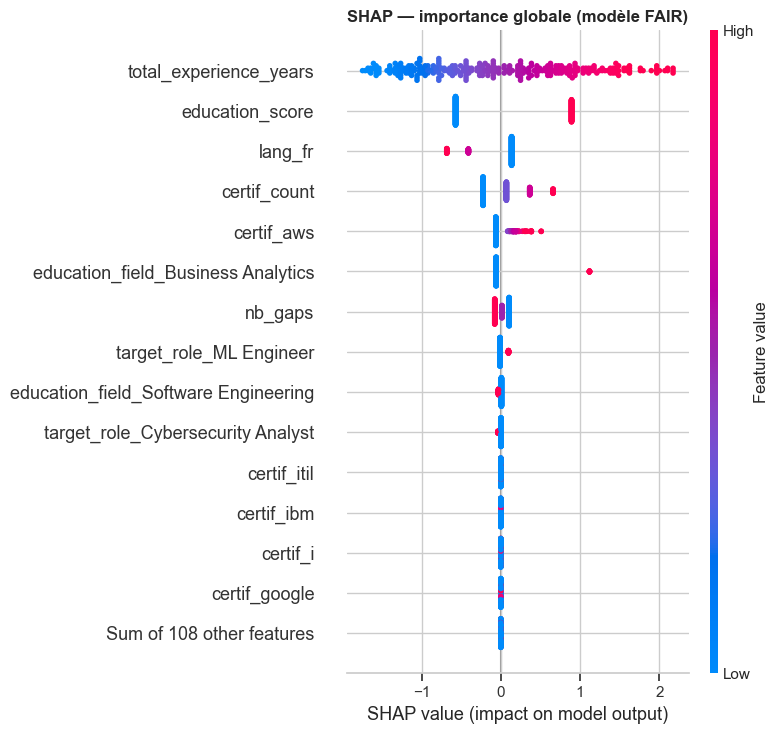

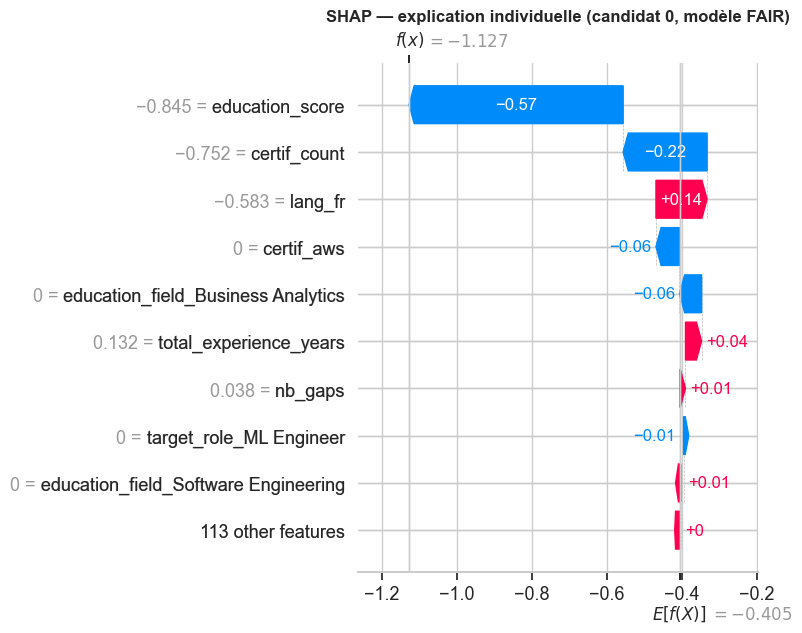

=== Impact SHAP moyen — features clés du modèle FAIR ===
  education_score                     |SHAP|=0.7113  → FAVORISE (+)
  lang_fr                             |SHAP|=0.2354  → PÉNALISE (−)
  lang_en                             |SHAP|=0.0000  → PÉNALISE (−)
  total_experience_years              |SHAP|=0.8544  → PÉNALISE (−)
  certif_count                        |SHAP|=0.2281  → FAVORISE (+)


In [16]:
import shap

# SHAP sur le MODÈLE FAIR (celui qui sera déployé). On veut comprendre
# quelles features pilotent les décisions du modèle corrigé.
prep_fair = lr_fair.named_steps['preprocessor']
clf_fair  = lr_fair.named_steps['classifier']

ohe_names_fair = (prep_fair.named_transformers_['cat']
                  .named_steps['ohe']
                  .get_feature_names_out(CATEGORICAL_FEATURES).tolist())
skills_names_fair = [f'skill_{w}' for w in prep_fair.named_transformers_['skills'].get_feature_names_out()]
certif_names_fair = [f'certif_{w}' for w in prep_fair.named_transformers_['certif'].get_feature_names_out()]
feature_names_fair = NUMERIC_FEATURES_FAIR + ohe_names_fair + skills_names_fair + certif_names_fair

sample_size = min(300, len(X_all_fair))
X_sample = X_all_fair.sample(sample_size, random_state=RANDOM_STATE)
X_sample_t = prep_fair.transform(X_sample)
explainer = shap.LinearExplainer(clf_fair, X_sample_t, feature_names=feature_names_fair)
shap_values = explainer(X_sample_t)

# Plot 1 : beeswarm (importance globale + direction) sur le modèle FAIR
shap.plots.beeswarm(shap_values, max_display=15, show=False)
plt.title('SHAP — importance globale (modèle FAIR)', fontweight='bold')
plt.tight_layout()
plt.show()

# Plot 2 : waterfall (un candidat) sur le modèle FAIR
shap.plots.waterfall(shap_values[0], max_display=10, show=False)
plt.title('SHAP — explication individuelle (candidat 0, modèle FAIR)', fontweight='bold')
plt.tight_layout()
plt.show()

# Impact moyen des features encore présentes (focus sur les sensibles conservées)
shap_df = pd.DataFrame(shap_values.values, columns=feature_names_fair)
print('=== Impact SHAP moyen — features clés du modèle FAIR ===')
for feat in ['education_score', 'lang_fr', 'lang_en', 'total_experience_years', 'certif_count']:
    if feat in shap_df.columns:
        m_abs = shap_df[feat].abs().mean()
        m_val = shap_df[feat].mean()
        direction = 'FAVORISE (+)' if m_val > 0 else 'PÉNALISE (−)'
        print(f'  {feat:<35} |SHAP|={m_abs:.4f}  → {direction}')


## 11. Comparaison ancien vs nouveau modèle


In [17]:
# Prédictions du modèle équitable sur l'ensemble pour pouvoir filtrer test
df_audit['proba_fair'] = lr_fair.predict_proba(X_all_fair)[:, 1]
df_audit['pred_fair'] = (df_audit['proba_fair'] >= threshold_fair).astype(int)
df_audit_test = df_audit[df_audit['split'] == 'test'].copy()

comparison_rows = []
for label, col in sensitive_attrs.items():
    m_old, dp_old, eod_old = compute_fairness_metrics(df_audit_test, col, y_pred_col='pred')
    m_new, dp_new, eod_new = compute_fairness_metrics(df_audit_test, col, y_pred_col='pred_fair')
    comparison_rows.append({
        'Attribut': label,
        'DP — Ancien': round(dp_old, 3), 'DP — Nouveau': round(dp_new, 3),
        'EOD — Ancien': round(eod_old, 3) if not np.isnan(eod_old) else np.nan,
        'EOD — Nouveau': round(eod_new, 3) if not np.isnan(eod_new) else np.nan,
        'DI min — Ancien': round(m_old['disparate_impact'].min(), 3),
        'DI min — Nouveau': round(m_new['disparate_impact'].min(), 3),
    })
comp_df = pd.DataFrame(comparison_rows).set_index('Attribut')
print('=== Équité ANCIEN vs NOUVEAU (test set) ===')
display(comp_df)


=== Équité ANCIEN vs NOUVEAU (test set) ===


,DP — Ancien,DP — Nouveau,EOD — Ancien,EOD — Nouveau,DI min — Ancien,DI min — Nouveau
Attribut,,,,,,
Âge (groupe),0.504,0.444,1.000,0.667,0.181,0.111
Distance géographique,0.110,0.146,0.229,0.196,0.715,0.578
Francophonie,0.203,0.230,0.133,0.467,0.473,0.284
Niveau éducation,0.558,0.508,0.546,0.616,0.173,0.116
Prestige école,0.558,0.508,0.546,0.616,0.173,0.116


--- Ancien modèle ---
              precision    recall  f1-score   support

      Refusé       0.91      0.75      0.82        80
 Sélectionné       0.41      0.70      0.52        20

    accuracy                           0.74       100
   macro avg       0.66      0.72      0.67       100
weighted avg       0.81      0.74      0.76       100

ROC-AUC : 0.706

--- Nouveau modèle (équitable) ---
              precision    recall  f1-score   support

      Refusé       0.88      0.80      0.84        80
 Sélectionné       0.41      0.55      0.47        20

    accuracy                           0.75       100
   macro avg       0.64      0.68      0.65       100
weighted avg       0.78      0.75      0.76       100

ROC-AUC : 0.687


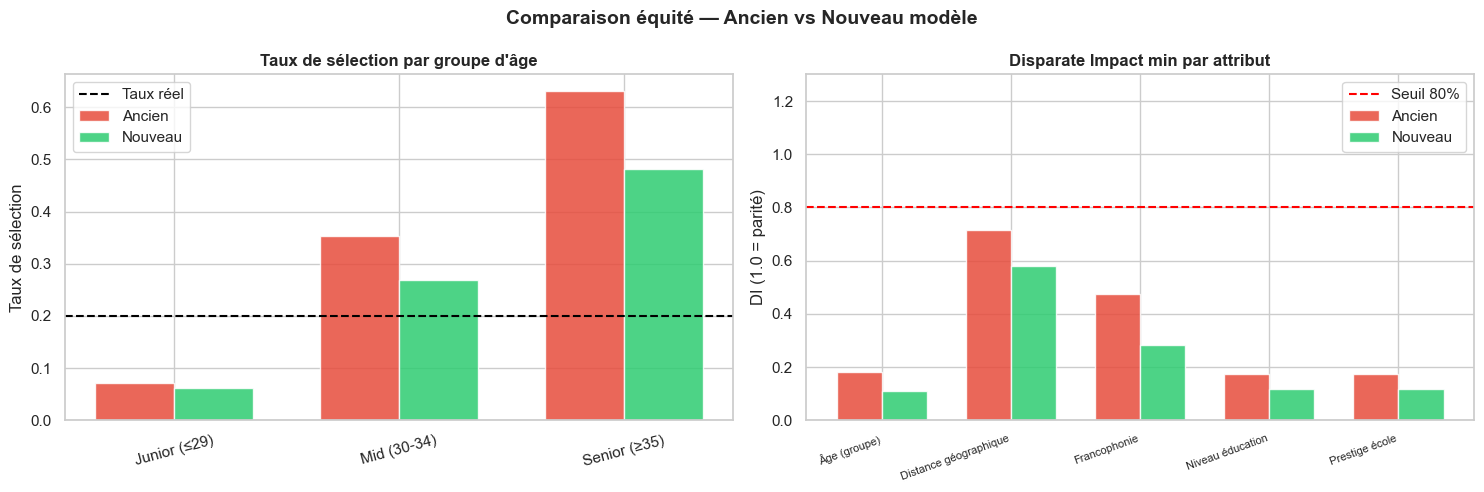

In [18]:
# Comparaison performances + visuel
X_te_orig = df_audit.drop(columns=['cv_id', TARGET, 'proba', 'pred',
                                   'proba_fair', 'pred_fair', 'split'] + GROUP_COLS).iloc[X_te_f.index]
y_proba_old_te = lr_pipeline.predict_proba(X_te_orig)[:, 1]
y_pred_old_te = (y_proba_old_te >= best_threshold).astype(int)

print('--- Ancien modèle ---')
print(classification_report(y_te_f, y_pred_old_te, target_names=['Refusé', 'Sélectionné']))
print(f'ROC-AUC : {roc_auc_score(y_te_f, y_proba_old_te):.3f}')
print()
print('--- Nouveau modèle (équitable) ---')
print(classification_report(y_te_f, y_pred_fair_te, target_names=['Refusé', 'Sélectionné']))
print(f'ROC-AUC : {roc_auc_score(y_te_f, y_proba_fair):.3f}')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
# Taux de sélection par âge
age_old = df_audit.groupby('age_group', observed=True)['pred'].mean()
age_new = df_audit.groupby('age_group', observed=True)['pred_fair'].mean()
x = np.arange(len(age_old)); w = 0.35
axes[0].bar(x - w / 2, age_old.values, w, label='Ancien', color='#e74c3c', alpha=0.85)
axes[0].bar(x + w / 2, age_new.values, w, label='Nouveau', color='#2ecc71', alpha=0.85)
axes[0].axhline(df_audit[TARGET].mean(), color='black', linestyle='--', lw=1.5, label='Taux réel')
axes[0].set_xticks(x); axes[0].set_xticklabels([str(g) for g in age_old.index], rotation=15)
axes[0].set_title('Taux de sélection par groupe d\'âge', fontweight='bold')
axes[0].set_ylabel('Taux de sélection'); axes[0].legend()

# DI min par attribut
di_comp = comp_df[['DI min — Ancien', 'DI min — Nouveau']]
x2 = np.arange(len(di_comp))
axes[1].bar(x2 - w / 2, di_comp['DI min — Ancien'], w, label='Ancien', color='#e74c3c', alpha=0.85)
axes[1].bar(x2 + w / 2, di_comp['DI min — Nouveau'], w, label='Nouveau', color='#2ecc71', alpha=0.85)
axes[1].axhline(0.80, color='red', linestyle='--', lw=1.5, label='Seuil 80%')
axes[1].set_xticks(x2); axes[1].set_xticklabels(di_comp.index, rotation=20, ha='right', fontsize=8)
axes[1].set_title('Disparate Impact min par attribut', fontweight='bold')
axes[1].set_ylabel('DI (1.0 = parité)'); axes[1].legend(); axes[1].set_ylim(0, 1.3)

plt.suptitle('Comparaison équité — Ancien vs Nouveau modèle', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 12. Explication individuelle d'une décision

Pour répondre à l'**Art. 14 de l'AI Act** (supervision humaine effective), on décompose la prédiction en contributions log-odds par feature : le recruteur voit *quelles features* ont fait pencher la balance vers acceptation ou refus.


=== Candidat cv_0001.txt ===
Rôle visé        : Software Engineer
Expérience       : 2.4 ans
Score éducation  : 3
Proba prédite    : 9.7%  |  Seuil : 63.5%  |  ❌ REFUSÉ



,feature,contribution,abs
0,total_experience_years,-0.968542,0.968542
4,education_score,-0.609729,0.609729
6,certif_count,-0.207090,0.207090
8,lang_fr,0.181791,0.181791
1,nb_gaps,-0.003029,0.003029


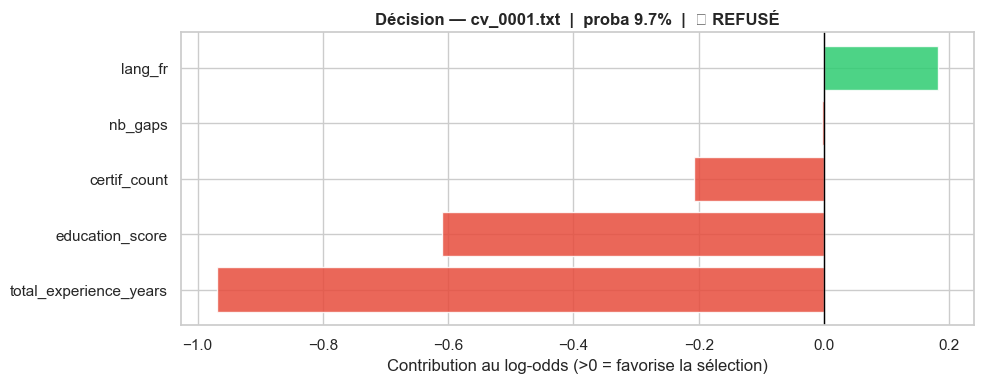

In [19]:
def explain_prediction_logistic(pipeline, sample_df, feature_names_num, feature_names_cat):
    """Décomposition log-odds des contributions par feature."""
    clf = pipeline.named_steps['classifier']
    prep = pipeline.named_steps['preprocessor']
    X_transformed = prep.transform(sample_df)
    row = X_transformed[0].toarray()[0] if hasattr(X_transformed, 'toarray') else X_transformed[0]

    contributions = row * clf.coef_[0]
    log_odds = clf.intercept_[0] + contributions.sum()
    proba = 1 / (1 + np.exp(-log_odds))

    ohe = prep.named_transformers_['cat'].named_steps['ohe'].get_feature_names_out(feature_names_cat)
    skills = [f'skill_{w}' for w in prep.named_transformers_['skills'].get_feature_names_out()]
    certifs = [f'certif_{w}' for w in prep.named_transformers_['certif'].get_feature_names_out()]
    feats = list(feature_names_num) + list(ohe) + skills + certifs

    contrib_df = pd.DataFrame({'feature': feats, 'contribution': contributions})
    contrib_df['abs'] = contrib_df['contribution'].abs()
    return proba, contrib_df[contrib_df['abs'] > 0].sort_values('abs', ascending=False)


# Exemple sur le 1er candidat
sample_idx = 0
sample = X_all_fair.iloc[[sample_idx]]
info = df_audit.iloc[sample_idx]
proba, contrib = explain_prediction_logistic(lr_fair, sample, NUMERIC_FEATURES_FAIR, CATEGORICAL_FEATURES)
decision = '✅ SÉLECTIONNÉ' if proba >= threshold_fair else '❌ REFUSÉ'

print(f'=== Candidat {info["cv_id"]} ===')
print(f'Rôle visé        : {info["target_role"]}')
print(f'Expérience       : {info["total_experience_years"]} ans')
print(f'Score éducation  : {info["education_score"]}')
print(f'Proba prédite    : {proba:.1%}  |  Seuil : {threshold_fair:.1%}  |  {decision}')
print()
display(contrib.head(10))

# Graphique
top = contrib.head(10).sort_values('contribution')
fig, ax = plt.subplots(figsize=(10, max(4, len(top) * 0.5)))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in top['contribution']]
ax.barh(top['feature'], top['contribution'], color=colors, alpha=0.85, edgecolor='white')
ax.axvline(0, color='black', lw=1)
ax.set_title(f'Décision — {info["cv_id"]}  |  proba {proba:.1%}  |  {decision}', fontweight='bold')
ax.set_xlabel('Contribution au log-odds (>0 = favorise la sélection)')
plt.tight_layout()
plt.show()


## 13. Sauvegarde du modèle équitable


In [20]:
import os
os.makedirs('../models', exist_ok=True)

fair_model_data = {
    'pipeline': lr_fair,
    'optimal_threshold': float(threshold_fair),
    'removed_features': ['age', 'distance_ville_haute_km',
                         'lang_de', 'lang_es', 'lang_it', 'lang_other_score_sum'],
    'numeric_features': NUMERIC_FEATURES_FAIR,
    'categorical_features': CATEGORICAL_FEATURES,
    'audit_summary': summary_df.to_dict(),
    'fairness_metrics': {label: m.to_dict() for label, m in all_metrics.items()},
}
joblib.dump(fair_model_data, '../models/model_classification_cv_FAIR.joblib')

print('Modèle équitable sauvegardé ✓')
print(f'Seuil global      : {threshold_fair:.4f}')
print(f'Features retirées : age, distance_ville_haute_km, lang_de, lang_es, lang_it, lang_other_score_sum')
print(f'Taille            : {os.path.getsize("../models/model_classification_cv_FAIR.joblib") / 1024:.1f} KB')


Modèle équitable sauvegardé ✓
Seuil global      : 0.6352
Features retirées : age, distance_ville_haute_km, lang_de, lang_es, lang_it, lang_other_score_sum
Taille            : 63.2 KB


## 14. Synthèse de l'audit & recommandations

### Constat principal — Equal Opportunity sur l'âge (ancien modèle)

| Groupe d'âge | n_test | n qualifiés | Selection rate | TPR | Base rate |
|---|---|---|---|---|---|
| Junior (≤29) | 36 | 2 | 11.1% | **0.0%** ❌ | 5.5% |
| Mid (30-34) | 38 | 12 | 36.8% | 66.7% | 31.6% |
| Senior (≥35) | 26 | 6 | 61.5% | **100%** | 23.1% |

→ TPR Junior = 0%, TPR Senior = 100%, **EOD = 1.00**. L'ancien modèle ne détecte aucun candidat Junior pourtant qualifié. Chi² conditionnel à `y_true=1` confirme : **p = 0.026**.

### Bilan ancien vs nouveau modèle

| Indicateur | Ancien | Nouveau | Δ |
|---|---|---|---|
| **EOD Âge** (métrique clé) | 1.00 | 0.67 | **−0.33** ✅ |
| EOD Éducation | 0.55 | 0.62 | +0.07 |
| ROC-AUC test | 0.706 | 0.687 | −0.019 |
| Recall (sélectionné) | 0.70 | 0.55 | −0.15 |

→ Le nouveau modèle améliore l'**Equal Opportunity sur l'âge** au prix d'un léger recul du recall global. Trade-off **assumé et documenté** : dans un système de recrutement à haut risque, **l'équité prime sur la performance brute**.

### Effet de bord — EOD francophonie

La suppression de `lang_de`, `lang_es`, `lang_it` et `lang_other_score_sum` reporte mécaniquement du poids sur `lang_fr`, qui est conservée comme compétence professionnelle légitime dans le contexte belgo-européen. Conséquence visible :

| Attribut | EOD ancien | EOD nouveau | Δ |
|---|---|---|---|
| Francophonie | 0.13 | 0.47 | +0.33 ⚠ |
| Éducation | 0.55 | 0.62 | +0.07 ⚠ |

L'amélioration ciblée sur l'âge se paie d'une dégradation sur la francophonie. Le DI min se dégrade aussi sur tous les attributs (cf. §11). Ces effets sont **attendus mécaniquement** quand on retire des features sans les remplacer, mais ils restent à surveiller : un audit de second tour devrait évaluer si `lang_fr` mérite à son tour d'être pondérée ou retirée selon la composition réelle des recrutements de LuxTalent. C'est un trade-off honnêtement documenté, pas une victoire complète.

### Réponses au cahier des charges WP2 (§I)

1. *« Le système traite-t-il les candidats comparables de manière égale ? »* — **Non, pour l'âge** sur l'ancien modèle (EOD = 1.00). Corrigé partiellement sur le nouveau (0.67).
2. *« Y a-t-il des disparités mesurables ? »* — Oui sur âge et éducation (Chi² significatif). Non sur distance ni francophonie marginale (avant correction).
3. *« Sont-elles justifiées par le poste ? »* — Partiellement pour l'éducation (Master+ plus qualifié) et les rôles techniques (cf. §7b). L'écart de TPR par âge n'est *pas* justifié — c'est un vrai biais.
4. *« Le modèle peut-il être amélioré ? »* — Oui : EOD Âge réduit de 33 points avec le modèle FAIR.
5. *« Les décisions peuvent-elles être rendues plus transparentes ? »* — Oui, via L1 (§8) + SHAP global (§10) + log-odds individuel (§12).

### Robustesse statistique appliquée

- Tests d'indépendance Fisher exact (2×2) ou Chi² Pearson (3×2) — §5.
- IC bootstrap 95% sur l'EOD (1000 ré-échantillonnages) — §5b.
- Calibration par groupe (3ᵉ jambe DP/EO/Calibration, lien Art. 15 AI Act) — §5c.

### Limites

- Test set de **100 candidats** (20 positifs) → IC bootstrap larges, cellules intersectionnelles à effectif <10.
- Les attributs sensibles "vrais" (genre, nationalité, origine ethnique) **ne sont pas dans le dataset** — l'audit travaille sur des proxies.
- Chi² 3×2 avec cellules <5 : l'idéal serait Fisher-Freeman-Halton, non disponible dans scipy.

### Recommandations

- Audit **annuel** avec un test set d'au moins 500 candidats.
- Documenter les décisions contestées (RGPD Art. 22 — droit à l'explication).
- Boucle de feedback humain pour les cas limites (proba ∈ [seuil ± 5%]).
- Surveiller `lang_fr` au prochain audit (feature ayant hérité du poids des langues retirées).
- Former les recruteurs aux biais algorithmiques.

### Apports de la conférence intégrés à cet audit

1. **Justice & Équité** → choix de l'EOD plutôt que de la DP seule.
2. **Intersectionnalité** → analyses croisées Âge × Francophonie / Géographie (§7).
3. **Explicabilité** → triple couche L1 + SHAP + log-odds individuel (Art. 13 et 14 AI Act).
4. **Non-malfaisance** → minimisation des données (`age`, distance, langues exotiques retirées par principe).
5. **Durabilité / IA frugale** → régression logistique L1 préférée à un modèle deep, intrinsèquement explicable et peu coûteuse.
